#**1**

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.fft import fft, fftfreq

In [127]:
import librosa
import scipy.integrate as integrate
from scipy.signal import find_peaks

In [10]:
signal, sr = librosa.load('/content/Sesiones_Fourier_Nota_CM_piano.mp3', sr=None)


In [11]:
print(f"Sample Rate: {sr}")
print(f"Signal Shape: {signal.shape}")

Sample Rate: 44100
Signal Shape: (152064,)


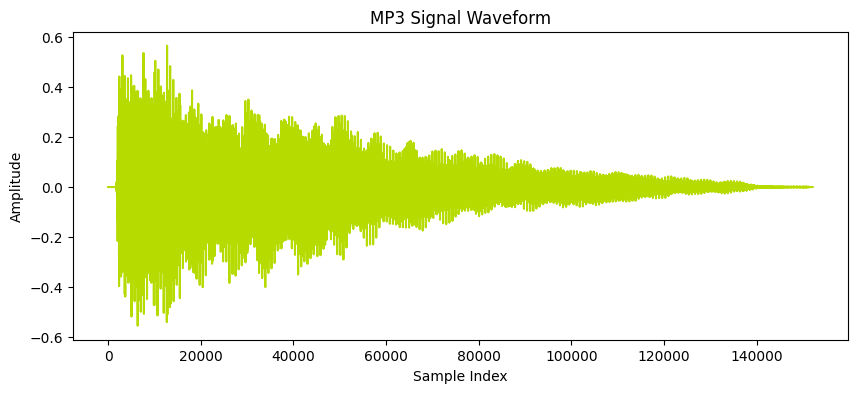

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(signal,'#B6DB00')
plt.title("MP3 Signal Waveform")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

In [177]:
N = len(signal)
yf = fft(signal)
xf = fftfreq(N,1/sr)

xf = xf[:N//2]
yf = np.abs(yf[:N//2])
yf=yf/np.max(yf)

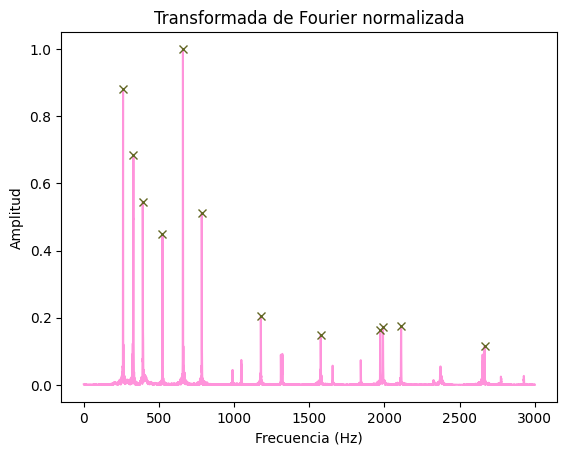

In [181]:
plt.plot(xf[xf<3000],yf[xf<3000],'#FF94DB')
picos, propiedades = find_peaks(yf,height=np.max(yf)*0.1,distance=20)
plt.plot(xf[picos],yf[picos],'x',color='#626624')
plt.title("Transformada de Fourier normalizada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.show()

#**2**

In [167]:
def g(t,w):
    return 1./(2*np.pi)*np.exp(-1j*2*np.pi*w*t)

from scipy import interpolate

def FT(x,y):
    '''Integrate the Fourier Transform of f(t) at frequency w'''

    #Interpolate f(t) to integrate
    f_interp = interpolate.interp1d(x, y, kind='cubic', fill_value='extrapolate')
    ft = lambda t: f_interp(t)

    # range of t to integrate
    t = np.linspace(x.min(), x.max(), 400)

    # FRECUENCIES spectrum to looking for peaks
    w = np.linspace(0.1,3000,500)

    df = []
    for i in range(len(w)):
        ARew = integrate.quad(lambda t: ft(t)*g(t,w[i]).real, t.min(), t.max())[0]
        AImw = integrate.quad(lambda t: ft(t)*g(t,w[i]).imag, t.min(), t.max())[0]
        AMP = np.sqrt(ARew**2 + AImw**2)
        ANG = np.arctan2(AImw, ARew)
        df.append([w[i], ARew, AImw, AMP, ANG])
    df = pd.DataFrame(df, columns=['w', 'ReTw', 'ImTw', 'AMP', 'ANG'])
    return df

In [169]:
x=np.linspace(0, len(signal)/sr, len(signal))
df=FT(x,signal)

/tmp/ipykernel_2255/2333462837.py:21: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  ARew = integrate.quad(lambda t: ft(t)*g(t,w[i]).real, t.min(), t.max())[0]
/tmp/ipykernel_2255/2333462837.py:22: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  AImw = integrate.quad(lambda t: ft(t)*g(t,w[i]).imag, t.min(), t.max())[0]
/tmp/ipykernel_2255/2333462837.py:22: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  AImw = integrate.quad(lambda t: ft(t)*g(t,w[i]).imag, t.min(), t.max())[0]
/tmp/ipykernel_2255/2333462837.py:21: Inte

/tmp/ipykernel_2255/1363308236.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


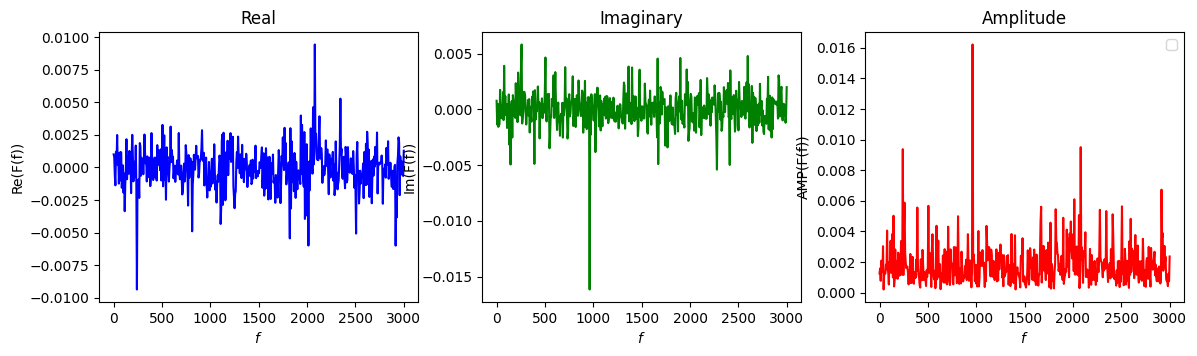

In [170]:
plt.figure(figsize=(14,3.5))
######## REAL ###########
plt.subplot(1,3,1)
plt.plot(df.w, df.ReTw,'b-')
plt.title('Real')
plt.xlabel('$f$')
plt.ylabel('Re(F(f))')
######### IMAG ##########
plt.subplot(1,3,2)
plt.plot(df.w, df.ImTw,'g-')
plt.title('Imaginary')
plt.xlabel('$f$')
plt.ylabel('Im(F(f))')
######### AMP ##########
plt.subplot(1,3,3)
plt.plot(df.w, df.AMP,'r-')

plt.title('Amplitude')
plt.xlabel('$f$')
plt.ylabel('AMP(F(f))')
plt.legend(loc='best')
plt.show()

In [171]:
AMP=df.AMP/df.AMP.max()
picos2,propiedades2= find_peaks(AMP,height=np.max(AMP)*0.1,distance=20)

Text(0, 0.5, 'AMP(F(f))')

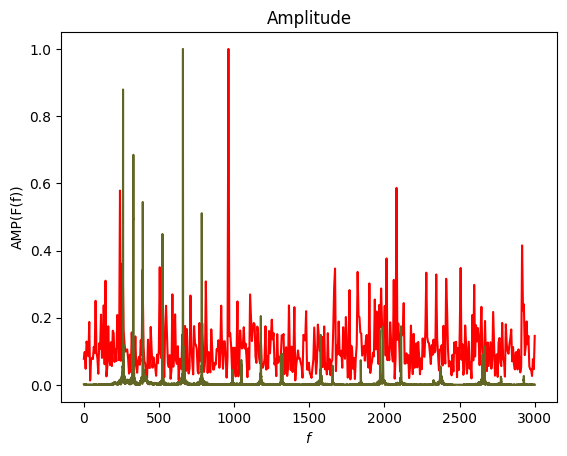

In [183]:


plt.plot(df.w, AMP,'r-')
plt.plot(xf[xf<3000],yf[xf<3000],color='#626624')
# plt.plot(df.w[picos2],df.AMP[picos2],'x',color='black')
plt.title('Amplitude')
plt.xlabel('$f$')
plt.ylabel('AMP(F(f))')


El cóigo hecho en clase es demasiado ineficente comparado con el algoritmo de scipy tomando un tiempo de cómputo de más e un minuto, además se puede observar como la amplitud es diferente al igual que el valor de sus frecencias.

Nota 3.5 Revisado... Entrega tarde. Quizás mal el git push!